In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


df= pd.read_csv('../data collections/heart (3).csv')

In [10]:
print(df.head())
print(df.nunique())
print(df.info())
df.describe()



scaler= StandardScaler()

   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   52    1   0       125   212    0  ...      0      1.0      2   2     3       0
1   53    1   0       140   203    1  ...      1      3.1      0   0     3       0
2   70    1   0       145   174    0  ...      1      2.6      0   0     3       0
3   61    1   0       148   203    0  ...      0      0.0      2   1     3       0
4   62    0   0       138   294    1  ...      0      1.9      1   3     2       0

[5 rows x 14 columns]
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null 

In [17]:
X= df.drop(["target"], axis=1)

y= df.target

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


for c in [0.01, 0.1, 1, 10, 100]:
    model= SVC(kernel="linear", C=c, random_state=0)
    model.fit(X_train_scaled, y_train)
    print('c:', c, 'score:', model.score(X_train_scaled, y_train))
    print('c:', c, 'score:', model.score(X_test_scaled, y_test))

for c in [0.1, 1, 10, 100]:
    for g in ["scale", 0.01, 0.1, 1]:
        model2 = SVC(kernel="rbf", C=c, gamma=g, random_state=0)
        model2.fit(X_train_scaled, y_train)
        print("C:", c, "gamma:", g, "score:", model2.score(X_test_scaled, y_test))

#C: 10 gamma: 0.1 score: 0.9853658536585366



c: 0.01 score: 0.8365853658536585
c: 0.01 score: 0.848780487804878
c: 0.1 score: 0.8426829268292683
c: 0.1 score: 0.8341463414634146
c: 1 score: 0.8426829268292683
c: 1 score: 0.8439024390243902
c: 10 score: 0.8426829268292683
c: 10 score: 0.8390243902439024
c: 100 score: 0.8451219512195122
c: 100 score: 0.848780487804878
C: 0.1 gamma: scale score: 0.8634146341463415
C: 0.1 gamma: 0.01 score: 0.8390243902439024
C: 0.1 gamma: 0.1 score: 0.8585365853658536
C: 0.1 gamma: 1 score: 0.5121951219512195
C: 1 gamma: scale score: 0.8829268292682927
C: 1 gamma: 0.01 score: 0.8731707317073171
C: 1 gamma: 0.1 score: 0.8926829268292683
C: 1 gamma: 1 score: 1.0
C: 10 gamma: scale score: 0.975609756097561
C: 10 gamma: 0.01 score: 0.8634146341463415
C: 10 gamma: 0.1 score: 0.9853658536585366
C: 10 gamma: 1 score: 1.0
C: 100 gamma: scale score: 0.9853658536585366
C: 100 gamma: 0.01 score: 0.9073170731707317
C: 100 gamma: 0.1 score: 0.9853658536585366
C: 100 gamma: 1 score: 1.0


In [16]:
model3= SVC(C=10, gamma=0.1)

model3.fit(X_train_scaled, y_train)
predictions= model3.predict(X_test_scaled)
print(model3.score(X_train_scaled, y_train))
print(model3.score(X_test_scaled, y_test))

1.0
0.9853658536585366


     feature  importance_mean  importance_std
11        ca         0.109268        0.018016
2         cp         0.097073        0.013875
1        sex         0.092683        0.014956
12      thal         0.057561        0.008393
7    thalach         0.055610        0.008780
6    restecg         0.048780        0.010232
5        fbs         0.047317        0.010919
0        age         0.044878        0.010864
8      exang         0.031220        0.005854
10     slope         0.031220        0.009559
9    oldpeak         0.031220        0.012758
4       chol         0.029756        0.010787
3   trestbps         0.019512        0.007235


<Axes: ylabel='feature'>

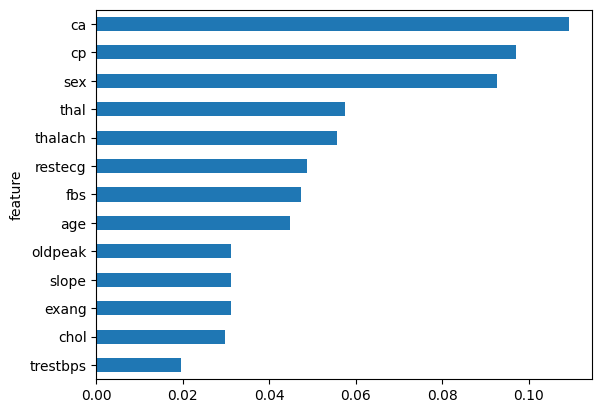

In [20]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model3,          # din tränade modell
    X_test_scaled,          # helst validation/test-data
    y_test,
    n_repeats=10,
    random_state=0
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

print(importance_df)

importance_df.sort_values("importance_mean").plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False
)